In [52]:
import os
import xgboost as xgb
import sklearn
import pandas as pd
from sentence_transformers import SentenceTransformer
import sklearn.neural_network as nn
import numpy as np
from sklearn.metrics import mean_squared_error
from tqdm import tqdm
from collections import defaultdict
import matplotlib.pyplot as plt


In [2]:
# Load in the split dataframe.
df = pd.read_csv("../data/interim/folds.csv")
df

,id,SMILES,Tg,FFV,Tc,Density,Rg,fold
0,87817,*CC(*)c1ccccc1C(=O)OCCCCCC,NaN,0.374645,0.205667,NaN,NaN,1
1,106919,*Nc1ccc([C@H](CCC)c2ccc(C3(c4ccc([C@@H](CCC)c5...,NaN,0.370410,NaN,NaN,NaN,3
2,388772,*Oc1ccc(S(=O)(=O)c2ccc(Oc3ccc(C4(c5ccc(Oc6ccc(...,NaN,0.378860,NaN,NaN,NaN,3
3,519416,*Nc1ccc(-c2c(-c3ccc(C)cc3)c(-c3ccc(C)cc3)c(N*)...,NaN,0.387324,NaN,NaN,NaN,4
4,539187,*Oc1ccc(OC(=O)c2cc(OCCCCCCCCCOCC3CCCN3c3ccc([N...,NaN,0.355470,NaN,NaN,NaN,4
...,...,...,...,...,...,...,...,...
7968,2146592435,*Oc1cc(CCCCCCCC)cc(OC(=O)c2cccc(C(*)=O)c2)c1,NaN,0.367498,NaN,NaN,NaN,2
7969,2146810552,*C(=O)OCCN(CCOC(=O)c1ccc2c(c1)C(=O)N(c1cccc(N3...,NaN,0.353280,NaN,NaN,NaN,3
7970,2147191531,*c1cc(C(=O)NCCCCCCCC)cc(N2C(=O)c3ccc(-c4ccc5c(...,NaN,0.369411,NaN,NaN,NaN,2
7971,2147435020,*C=C(*)c1ccccc1C,261.662355,NaN,NaN,NaN,NaN,0


In [4]:
# Now let us create embeddings for each SMILES string.
model = SentenceTransformer("Derify/ChemMRL-alpha")
df['embedding'] = [model.encode(x) for x in df['SMILES']]


## Linear Models

## MLP Regressors

In [50]:
# Score dict
scores = defaultdict(list)

# Now let us create a simple model for each of the individual properties.
for prop in tqdm(['Tg', 'FFV', 'Tc', 'Density', 'Rg']):
    # Iterate through each fold.
    for fold in df['fold'].unique():
        # Create test and train folds.
        test = df[df['fold'] == fold].dropna(subset=prop)
        train = df[df['fold'] != fold].dropna(subset=prop)

        # Create y vars.
        y_train = np.array(train[prop])
        y_test = np.array(test[prop])
        
        X_train = np.row_stack(train['embedding'].to_numpy())
        X_test = np.row_stack(test['embedding'].to_numpy())
        model = nn.MLPRegressor(random_state = 42, max_iter=2000, tol=0.1)
        model.fit(X_train, y_train)
        y_predict = model.predict(X_test)
        score = mean_squared_error(y_predict, y_test)
        scores[prop].append(score)
        


    
    

  0%|                                                     | 0/5 [00:00<?, ?it/s]/home/andrewlutsky/miniconda3/envs/openpoly/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/andrewlutsky/miniconda3/envs/openpoly/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/andrewlutsky/miniconda3/envs/openpoly/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
100%|█████████████████████████████████████████████| 5/5 [01:29<00:00, 17.80s/it]


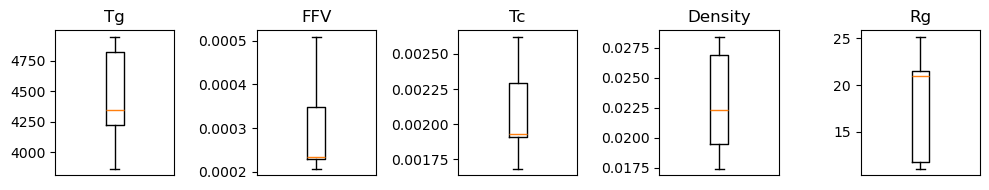

In [64]:
fig, axs = plt.subplots(1,5, figsize=(10, 2))
for idx, score in enumerate(['Tg', 'FFV', 'Tc', 'Density', 'Rg']):
    axs[idx].boxplot(scores[score])
    axs[idx].set_xticks([])
    axs[idx].set_title(score)

plt.tight_layout()
plt.show()